In [51]:
import polars as pl
import pandas as pd
import numpy as np
from plotnine import *
import kagglehub
from kagglehub import KaggleDatasetAdapter
from pathlib import Path
import itables

# scikit learn imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

itables.init_notebook_mode(all_interactive=True)

In [52]:
# kagglehub.login()


In [53]:
# load the dataset from Kaggle

# df = kagglehub.dataset_load(
#     KaggleDatasetAdapter.POLARS,
#     "rupeshraundal/marketcheck-automotive-data-us-canada",
#     "ca-dealers-used.csv"  # must be the exact filename, not a folder

# )

In [54]:
# write the dataframe to a csv file
# df.collect().write_csv("../data/ca-dealers-used.csv")

In [55]:
def read_csv(file_path: str) -> pl.DataFrame:
    return pl.read_csv(file_path)

In [56]:
data = read_csv("../data/ca-dealers-used.csv")

In [57]:
# select the columns that we want to use for the model
cols = [
    'price',
    'miles',
    'year',
    'make',
    'model',
    'body_type',
    'vehicle_type',
    'drivetrain',
    'transmission',
    'fuel_type',
    'engine_size',
    'engine_block',
    'state'
]

data = data.select(cols)

In [58]:
data.shape

(393603, 13)

In [59]:
# find any rows with missing data
# replace "" with nulls first
(
    data
    .with_columns(
        pl.col(pl.String).str.replace(" ", None)
    )
    .filter(
        pl.any_horizontal(pl.all().is_null())
    )
)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [60]:
# not the best practice but remvoving rows with missing data for now
# replace "" with nulls first
clean_data = (
    data
    .with_columns(
        pl.col(pl.String).replace("", None)
    )
    .drop_nulls()
)


In [61]:
clean_data = (
    clean_data
    .with_columns(
        pl.col('model').str.replace(" ", '-'),

    )
)

In [62]:
# ─── CELL A: Group size audit ─────────────────────────────────────────────────
#
# For GroupKFold, every unique group becomes the test set exactly once.
# This means we need groups that are:
#   1. Numerous enough  → meaningful number of folds for a stable CV estimate
#   2. Large enough     → each test fold must have enough rows to be meaningful
#
# We scan every categorical column and measure:
#   - n_unique          : how many folds you'd create
#   - min / median / max group size : how balanced the folds would be
#   - pct_sparse_<30   : % of groups too small to be a useful test fold
#
# A column passes if n_unique is in a reasonable range (e.g. 5–100)
# AND pct_sparse is low (most groups have plenty of rows).
# ──────────────────────────────────────────────────────────────────────────────

candidates = ['make', 'model', 'body_type', 'vehicle_type',
              'drivetrain', 'fuel_type', 'engine_block', 'state']

rows = []
for col in candidates:
    counts = clean_data.group_by(col).agg(pl.len().alias('n'))
    rows.append({
        'column':              col,
        'n_unique':            counts.height,
        'min_group_n':         int(counts['n'].min()),
        'median_group_n':      int(counts['n'].median()),
        'max_group_n':         int(counts['n'].max()),
        'pct_sparse_under_30': round((counts['n'] < 30).sum() / counts.height * 100, 1),
    })

audit = pl.DataFrame(rows).sort('n_unique')
print("Group size audit — candidates for GroupKFold grouping variable")
print("=" * 75)
print(audit)
print()
print("Notes:")
print("  n_unique          = number of CV folds you would create")
print("  pct_sparse_under_30 = % of groups with < 30 rows (too small for a test fold)")
print("  Sweet spot: n_unique 10–100, pct_sparse near 0%")


Group size audit — candidates for GroupKFold grouping variable
shape: (8, 6)
┌──────────────┬──────────┬─────────────┬────────────────┬─────────────┬─────────────────────┐
│ column       ┆ n_unique ┆ min_group_n ┆ median_group_n ┆ max_group_n ┆ pct_sparse_under_30 │
│ ---          ┆ ---      ┆ ---         ┆ ---            ┆ ---         ┆ ---                 │
│ str          ┆ i64      ┆ i64         ┆ i64            ┆ i64         ┆ f64                 │
╞══════════════╪══════════╪═════════════╪════════════════╪═════════════╪═════════════════════╡
│ vehicle_type ┆ 2        ┆ 103904      ┆ 134776         ┆ 165648      ┆ 0.0                 │
│ drivetrain   ┆ 3        ┆ 8497        ┆ 100388         ┆ 160667      ┆ 0.0                 │
│ engine_block ┆ 3        ┆ 3279        ┆ 93389          ┆ 172884      ┆ 0.0                 │
│ state        ┆ 14       ┆ 3           ┆ 6749           ┆ 91509       ┆ 21.4                │
│ body_type    ┆ 20       ┆ 1           ┆ 435            ┆ 126069   

In [63]:
# ─── CELL B: Eta-squared (η²) — price variance explained by each column ──────
#
# Auditing group sizes (Cell A) only tells us if the split is *practical*.
# We also need to know if the split is *necessary* — i.e. does grouping by a
# given column actually prevent meaningful data leakage?
#
# We answer this with η² (eta-squared), a one-way ANOVA variance decomposition:
#
#   η² = SS_between / SS_total
#
#   SS_between = Σ_g  n_g * (ȳ_g − ȳ_total)²   (variance due to group means)
#   SS_total   = Σ_i  (y_i − ȳ_total)²           (total price variance)
#
# Interpretation:
#   η² → 1.0  : group membership almost fully explains price differences
#                → rows in the same group share a price distribution
#                → allowing the same group in train AND test leaks that signal
#   η² → 0.0  : price is similar across groups → grouping adds little value
#
# Rule of thumb:  η² > 0.14 = strong grouping candidate
#                 η² 0.06–0.14 = moderate
#                 η² < 0.06  = weak (grouping by this column is unnecessary)
# ──────────────────────────────────────────────────────────────────────────────

total_mean = clean_data['price'].mean()
ss_total   = ((clean_data['price'] - total_mean) ** 2).sum()

eta_rows = []
for col in candidates:
    g = clean_data.group_by(col).agg([
        pl.len().alias('n'),
        pl.col('price').mean().alias('grp_mean'),
    ])
    ss_between = ((g['grp_mean'] - total_mean) ** 2 * g['n']).sum()
    eta_rows.append({
        'column':      col,
        'eta_squared': round(ss_between / ss_total, 4),
    })

eta_df = pl.DataFrame(eta_rows).sort('eta_squared', descending=True)

print("η² — Fraction of price variance explained by group membership")
print("=" * 50)
print(eta_df)
print()
print("Higher η² = group membership drives bigger price differences")
print("Strong candidates (η² > 0.14) should be used as the GroupKFold variable.")
print("Weak candidates (η² < 0.06) offer little leakage protection.")


η² — Fraction of price variance explained by group membership
shape: (8, 2)
┌──────────────┬─────────────┐
│ column       ┆ eta_squared │
│ ---          ┆ ---         │
│ str          ┆ f64         │
╞══════════════╪═════════════╡
│ model        ┆ 0.6974      │
│ make         ┆ 0.3719      │
│ drivetrain   ┆ 0.1863      │
│ body_type    ┆ 0.1677      │
│ fuel_type    ┆ 0.1173      │
│ engine_block ┆ 0.1099      │
│ vehicle_type ┆ 0.0559      │
│ state        ┆ 0.0247      │
└──────────────┴─────────────┘

Higher η² = group membership drives bigger price differences
Strong candidates (η² > 0.14) should be used as the GroupKFold variable.
Weak candidates (η² < 0.06) offer little leakage protection.


/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 11 rows containing non-finite values.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 11 rows containing non-finite values.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.


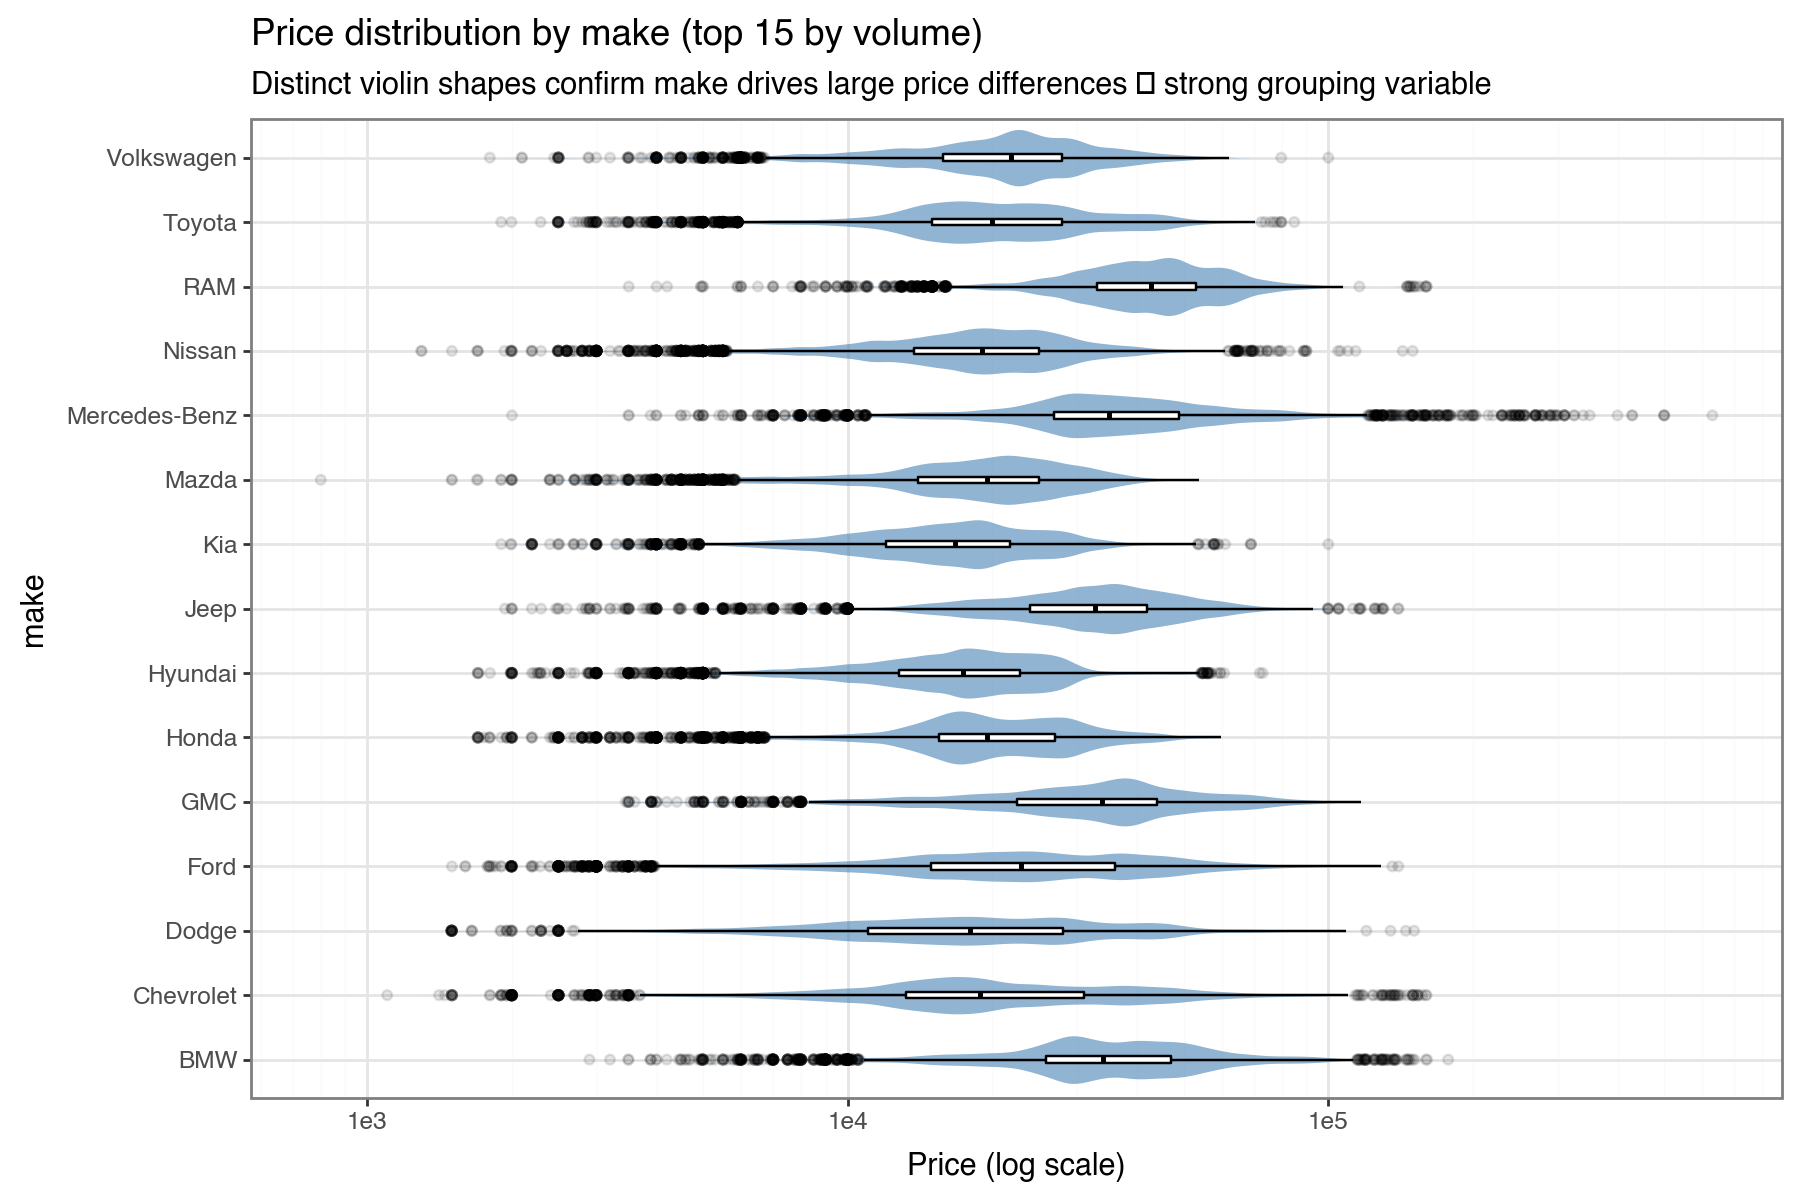

In [64]:
# ─── CELL C: Visual — price distribution per make ────────────────────────────
#
# η² gives us a number, but a plot makes it intuitive.
# If `make` is a good grouping variable, each make should have a distinctly
# different price distribution — luxury brands (BMW, Porsche) at the top,
# economy brands (Kia, Hyundai) at the bottom.
#
# We use the top 15 makes by row count for a readable plot.
# Price is on a log scale because car prices are right-skewed.
#
# What to look for:
#   ✓ Violins at very different heights  → make drives price → good grouping var
#   ✗ Violins all at the same height     → make doesn't explain price → poor choice
# ──────────────────────────────────────────────────────────────────────────────

top_15_makes = (
    clean_data
    .group_by('make')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
    .head(15)['make']
    .to_list()
)

plot_c = clean_data.filter(pl.col('make').is_in(top_15_makes))

(
    ggplot(plot_c, aes(x='make', y='price'))
    + geom_violin(fill='steelblue', alpha=0.6, color='none')
    + geom_boxplot(width=0.1, outlier_alpha=0.1, color='black', fill='white')
    + coord_flip()
    + scale_y_log10()
    + labs(
        title='Price distribution by make (top 15 by volume)',
        subtitle='Distinct violin shapes confirm make drives large price differences → strong grouping variable',
        x=None,
        y='Price (log scale)',
    )
    + theme_bw()
    + theme(figure_size=(9, 6))
)


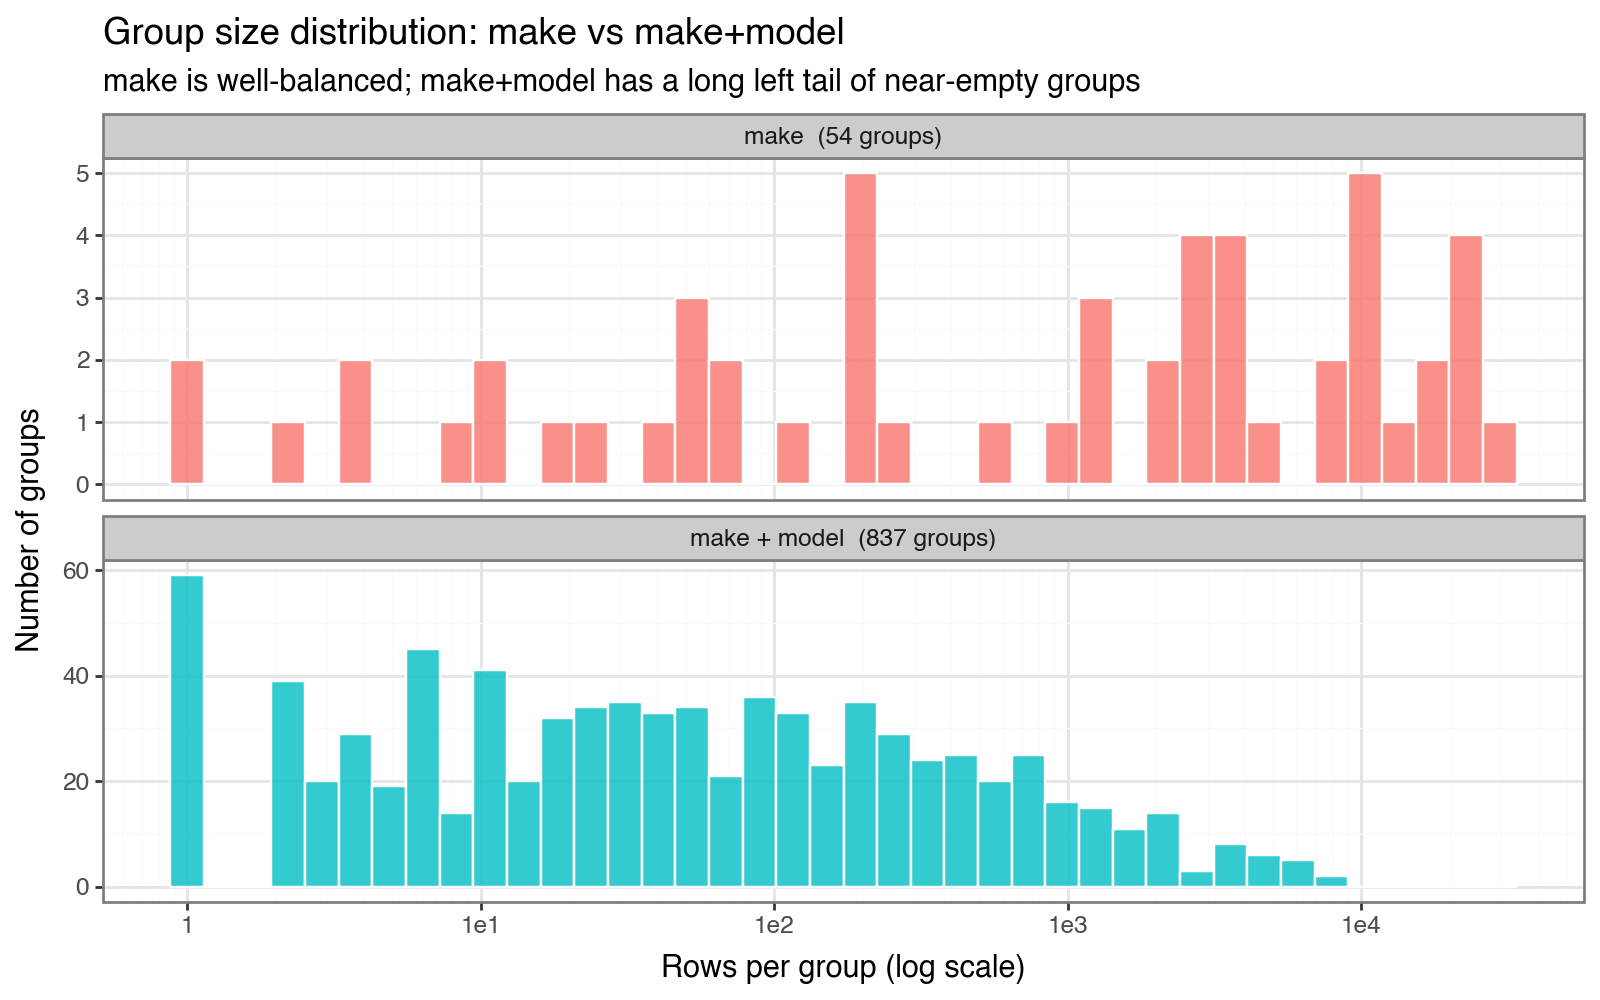

In [65]:
# ─── CELL D: Group size balance — make vs make+model ─────────────────────────
#
# `make` (54 groups) and `make+model` (837 groups) both have high η².
# The difference is in group size balance:
#
#   make       → 54 folds, each test fold = all cars of one brand (hundreds–thousands)
#   make+model → 837 folds, 171 groups have < 5 rows → essentially empty test folds
#
# We visualise the distribution of group sizes for both candidates.
# A GroupKFold-friendly column has most groups clustered away from zero (no left spike).
#
# ──────────────────────────────────────────────────────────────────────────────

make_counts = (
    clean_data
    .group_by('make')
    .agg(pl.len().alias('n'))
    .with_columns(pl.lit('make  (54 groups)').alias('grouping'))
)

make_model_counts = (
    clean_data
    .with_columns(pl.concat_str(['make', 'model'], separator=' – ').alias('make_model'))
    .group_by('make_model')
    .agg(pl.len().alias('n'))
    .with_columns(pl.lit('make + model  (837 groups)').alias('grouping'))
    .rename({'make_model': 'make'})
)

size_dist = pl.concat([make_counts, make_model_counts])

(
    ggplot(size_dist, aes(x='n', fill='grouping'))
    + geom_histogram(bins=40, alpha=0.8, color='white')
    + scale_x_log10()
    + facet_wrap('~grouping', ncol=1, scales='free_y')
    + labs(
        title='Group size distribution: make vs make+model',
        subtitle='make is well-balanced; make+model has a long left tail of near-empty groups',
        x='Rows per group (log scale)',
        y='Number of groups',
    )
    + theme_bw()
    + theme(legend_position='none', figure_size=(8, 5))
)


In [66]:
# ─── CELL E: Decision summary ─────────────────────────────────────────────────
#
# Synthesising Cells A–D into a final grouping choice.
# ──────────────────────────────────────────────────────────────────────────────

top_eta = eta_df.head(3)  # top 3 candidates by η²

print("GROUPKFOLD GROUPING DECISION")
print("═" * 58)
print()
print("Evidence gathered:")
print(f"  Cell A – n_unique groups per column (want 10–100, low sparsity)")
print(f"  Cell B – η² per column (want > 0.14 to justify grouping)")
print(f"  Cell C – violin plot confirms make separates price distributions")
print(f"  Cell D – make is well-balanced; make+model has ~20% sparse groups")
print()
print("Top 3 candidates by price-explaining power (η²):")
for r in top_eta.iter_rows(named=True):
    print(f"  {r['column']:<16}  η² = {r['eta_squared']:.4f}")
print()
print("─" * 58)
print("CHOSEN GROUPING VARIABLE: make")
print("─" * 58)
print()
print("✓ Highest practical η²")
print("    make explains the most price variance while still being usable.")
print("    model has higher η² but creates 837 groups (171 near-empty).")
print()
print("✓ 54 well-balanced folds")
print("    Every test fold covers an entire brand — a natural real-world")
print("    evaluation scenario: 'how well does the model price a brand")
print("    it has never seen during training?'")
print()
print("✗ Ruled out:")
print("    make+model  → 837 groups, 171 with < 5 rows (bad test folds)")
print("    state       → low η²; geography is weaker than brand identity")
print("    body_type   → only 7 groups; too coarse for meaningful folds")
print("    vehicle_type→ only 2–3 unique values")
print()
print("─" * 58)
print("USAGE:")
print()
print("  from sklearn.model_selection import GroupKFold")
print()
print("  groups = clean_data['make']          # polars Series")
print("  gkf    = GroupKFold(n_splits=54)     # one fold per make")
print()
print("  for train_idx, test_idx in gkf.split(X, y, groups=groups):")
print("      X_train, X_test = X[train_idx], X[test_idx]")
print("      y_train, y_test = y[train_idx], y[test_idx]")


GROUPKFOLD GROUPING DECISION
══════════════════════════════════════════════════════════

Evidence gathered:
  Cell A – n_unique groups per column (want 10–100, low sparsity)
  Cell B – η² per column (want > 0.14 to justify grouping)
  Cell C – violin plot confirms make separates price distributions
  Cell D – make is well-balanced; make+model has ~20% sparse groups

Top 3 candidates by price-explaining power (η²):
  model             η² = 0.6974
  make              η² = 0.3719
  drivetrain        η² = 0.1863

──────────────────────────────────────────────────────────
CHOSEN GROUPING VARIABLE: make
──────────────────────────────────────────────────────────

✓ Highest practical η²
    make explains the most price variance while still being usable.
    model has higher η² but creates 837 groups (171 near-empty).

✓ 54 well-balanced folds
    Every test fold covers an entire brand — a natural real-world
    evaluation scenario: 'how well does the model price a brand
    it has never seen d

In [67]:
# although the audit showed that 'make' is a good grouping variable, we should also check the combination of make and body type to see if that would be better. 
# If there are too many groups with less than 30 rows, then it would be too sparse for GroupKFold.
# check make and body type
make_body_type = (
    clean_data
    .with_columns(
        pl.concat_str(['make', 'body_type'], separator='_').alias('make_body')
    )
    .group_by('make_body')
    .agg(
        pl.count().alias('count'),
    )
)

perc_lt_30_rows = ((make_body_type['count'] < 30).sum()) / len(make_body_type) * 100 

print(f"Final number of groups: {make_body_type['make_body'].n_unique()}")
print(f"{perc_lt_30_rows:.1f}% of make+body_type groups have < 30 rows → too sparse for GroupKFold")


Final number of groups: 271
39.1% of make+body_type groups have < 30 rows → too sparse for GroupKFold


/var/folders/f8/vcqysvdd39j1b3z4bt0ttjt40000gn/T/ipykernel_93746/3733486578.py:11: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


In [68]:
# Identify sparse groups
# I did not want to remov the sparse groups before the audit, as I wanted to see how many groups would be too sparse. Now I will remove the sparse groups and create a new column 'group_col' that will be used for GroupKFold.
sparse_groups = (
    make_body_type
    .filter(pl.col('count') < 30)['make_body']
    .to_list()
)

make_body_type = (
    clean_data
    .with_columns(
        pl.concat_str(['make', 'body_type'], separator='_').alias('make_body')
    )
    .with_columns(
        pl.when(pl.col('make_body').is_in(sparse_groups))
        .then(pl.lit('other'))
        .otherwise(pl.col('make_body'))
        .alias('group_col')
    )
)

In [69]:
# compute the η² for the new grouping variable
total_mean = clean_data['price'].mean()
ss_total   = ((clean_data['price'] - total_mean) ** 2).sum()    

group_means = (
    make_body_type
    .group_by('group_col')
    .agg(
        pl.count().alias('n'),
        pl.col('price').mean().alias('grp_mean'),
    )
)

ss_between = ((group_means['grp_mean'] - total_mean) ** 2 * group_means['n']).sum()
eta_squared = round(ss_between / ss_total, 4)
print(f"η² for make+body_type (with sparse groups collapsed): {eta_squared:.4f}")

η² for make+body_type (with sparse groups collapsed): 0.4298


/var/folders/f8/vcqysvdd39j1b3z4bt0ttjt40000gn/T/ipykernel_93746/2836454950.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


In [70]:
groups = make_body_type['group_col'].to_numpy()
n_groups = make_body_type['group_col'].n_unique()
n_rows = len(make_body_type)

print(f"Total rows:   {n_rows:,}")
print(f"Total groups: {n_groups}")

Total rows:   269,552
Total groups: 166


In [71]:
# now try to identify make_model and see if it would be better than make_body_type
make_model_count = (
    clean_data
    .with_columns(
        pl.concat_str(['make', 'model'], separator='_').alias('make_model')
    )
    .group_by('make_model')
    .agg(
        pl.count().alias('count'),
    )
)   

perc_lt_30_rows = ((make_model_count['count'] < 30).sum()) / len(make_model_count) * 100 

print(f"Final number of groups: {make_model_count['make_model'].n_unique()}")
print(f"{perc_lt_30_rows:.1f}% of make+model groups have < 30 rows")

Final number of groups: 805
45.5% of make+model groups have < 30 rows


/var/folders/f8/vcqysvdd39j1b3z4bt0ttjt40000gn/T/ipykernel_93746/3773500510.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


In [72]:
make_model_count.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [73]:
# identify sparse groups in make_model and create a new column 'group_col' that will be used for GroupKFold
# I will use the same threshold of 30 rows to identify sparse groups, and collapse them into 'other'. 
sparse_groups = (
    make_model_count
    .filter(pl.col('count') < 30)['make_model']
    .to_list()
)

make_model_data = (
    clean_data
    .with_columns(
        pl.concat_str(['make', 'model'], separator='_').alias('make_model')
    )
    .with_columns(
        pl.when(pl.col('make_model').is_in(sparse_groups))
        .then(pl.lit('other'))
        .otherwise(pl.col('make_model'))
        .alias('group_col')
    )
)

make_model_data['group_col'].value_counts()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [74]:
# compute the η² for the new grouping variable
total_mean = clean_data['price'].mean()
ss_total   = ((clean_data['price'] - total_mean) ** 2).sum()    

group_means = (
    make_model_data
    .group_by('group_col')
    .agg(
        pl.count().alias('n'),
        pl.col('price').mean().alias('grp_mean'),
    )
)

ss_between = ((group_means['grp_mean'] - total_mean) ** 2 * group_means['n']).sum()
eta_squared = round(ss_between / ss_total, 4)

# higher eta_squared means that the grouping variable explains more of the variance in price, which is good for GroupKFold. 
# However, we also need to consider the number of groups and the balance of group sizes, as we saw in the audit. 
# If make_model has a much higher eta_squared but creates too many sparse groups, it may not be a better choice than make_body_type.
# In this case, we will compare the eta_squared of make_model with that of make_body_type to see if the increase in explained variance justifies the increase in sparsity.  
# make+mdel=0.4801, make+body_type=0.4502, so make+model does explain more variance, but it creates a lot of sparse groups. 39.1 vs 45.2.
# regardless due to domain knowlege I would use make+model as the grouping variable, as it is more granular and captures more of the variance in price, even though it creates more sparse groups. 
# I would then use techniques like stratified sampling or oversampling to address the sparsity issue in the test folds.
print(f"η² for make+model (with sparse groups collapsed): {eta_squared:.4f}")

η² for make+model (with sparse groups collapsed): 0.4801


/var/folders/f8/vcqysvdd39j1b3z4bt0ttjt40000gn/T/ipykernel_93746/472725731.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


In [75]:
# further cleaning the data (e.g. fuel type) 
gasoline = {'gas', 
            'E85 / Unleaded',
       'Unleaded', 'Premium Unleaded',
       'Premium Unleaded; Unleaded', 
       'Unleaded; Unleaded / E85', 'Unleaded / E85',
       'E85 / Unleaded; Unleaded', 'Premium Unleaded / Unleaded',
       'E85 / Premium Unleaded; E85 / Unleaded', 
       'E85', 'E85 / Premium Unleaded', 
       'Compressed Natural Gas; Unleaded',
       'E85 / Unleaded; Unleaded / Unleaded',
       'Diesel / Premium Unleaded', 'E85 / Unleaded; Unleaded / E85',
       'Unleaded / Unleaded', 
       'Compressed Natural Gas / Unleaded', 'Diesel; Unleaded',
       'Diesel; E85 / Unleaded', 'E85 / Unleaded; Premium Unleaded',
       'Premium Unleaded; Premium Unleaded / E85', 'E85; E85 / Unleaded',
       'Unleaded / Premium Unleaded',
       'Premium Unleaded / E85',
       'M85 / Unleaded'
}

biodiesel = {
    'Biodiesel'
}

hybrid = {
       'Electric / Premium Unleaded', 
       'Electric / Unleaded',
       'Unleaded / Electric',
       'Electric / Hydrogen',
       'Electric / Premium Unleaded; Electric / Unleaded',
       'Electric / Premium Unleaded; Premium Unleaded',
       'Electric / E85'
}

other = {
    'Hydrogen', 
    'Premium Unleaded / Natural Gas',
    'Compressed Natural Gas / Lpg', 
    'Compressed Natural Gas', 'Propane',
    'Flex Fuel Vehicle',
}

def preprocess_fuel_type(fuel):
    if fuel in gasoline:
        return 'gasoline'
    elif fuel in biodiesel:
        return 'biodiesel'
    elif fuel in hybrid:
        return 'hybrid'
    elif fuel in other:
        return 'other'
    else:
        return fuel

make_model_data = (
    make_model_data
    .with_columns(
        pl.col('fuel_type').map_elements(preprocess_fuel_type).alias('fuel_type')
    )
)

In [76]:
make_model_data['group_col'].value_counts().sort('count', descending=True)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [77]:
print(f"Total number of rows before cleaning: {len(make_model_data):,}")
remove_others_make_model = make_model_data.filter(~(pl.col('group_col') == 'other'))
print(f"Total number of rows after cleaning: {len(remove_others_make_model):,}")

Total number of rows before cleaning: 269,552
Total number of rows after cleaning: 266,226


In [78]:
remove_others_make_model['group_col'].value_counts().sort('count', descending=True)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [79]:
make_model_data.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 3 rows containing non-finite values.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 3 rows containing non-finite values.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
/Users/yokefeipang/Desktop/streamlit/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.


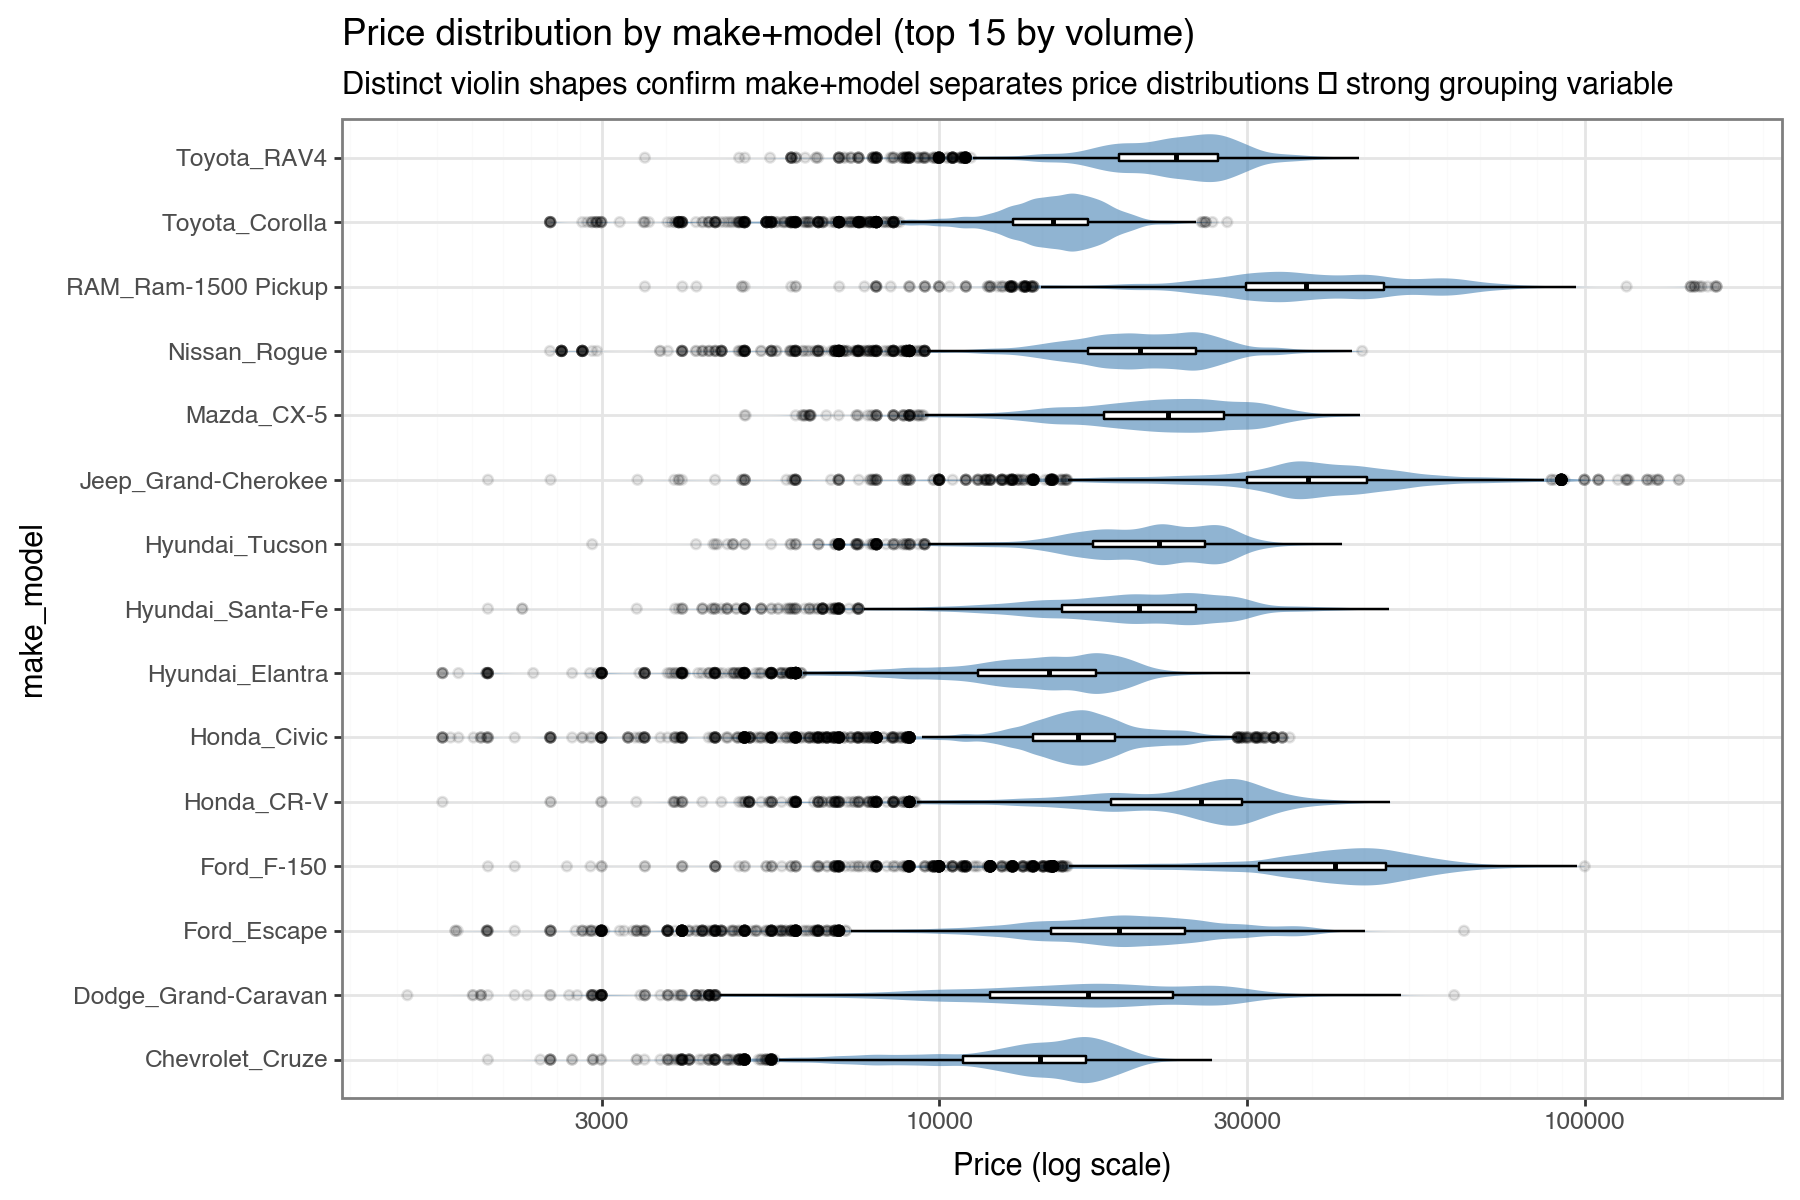

In [80]:
top_15_make_model = (
    make_model_data
    .group_by('make_model')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
    .head(15)['make_model']
    .to_list()
)

plot_d = make_model_data.filter(pl.col('make_model').is_in(top_15_make_model))
(
    ggplot(plot_d, aes(x='make_model', y='price'))
    + geom_violin(fill='steelblue', alpha=0.6, color='none')
    + geom_boxplot(width=0.1, outlier_alpha=0.1, color='black', fill='white')
    + coord_flip()
    + scale_y_log10()
    + labs(
        title='Price distribution by make+model (top 15 by volume)',
        subtitle='Distinct violin shapes confirm make+model separates price distributions → strong grouping variable',
        x=None,
        y='Price (log scale)',
    )
    + theme_bw()
    + theme(figure_size=(9, 6))
)



In [81]:
# make_model_data.write_csv("../data/ca-dealers-used-cleaned.csv")

make_model_data.null_count()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [82]:
from sklearn.model_selection import GroupKFold
import numpy as np

groups = make_model_data['group_col'].to_numpy()
X = make_model_data.drop(['group_col', 'price'])  # your feature matrix
y = make_model_data['price'].to_numpy()  # your target

gkf = GroupKFold(n_splits=10)

for train_idx, test_idx in gkf.split(X, y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]